In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt



In [2]:
# a)
n = 100
X = np.random.normal(0, 1, n)
epsilon = np.random.normal(0, 1, n)


In [3]:
# b)
beta0, beta1, beta2, beta3 = 1, 2, 3, 4
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + epsilon

In [4]:
# c)

data = pd.DataFrame({'Y': Y})
for i in range(1, 11):
    data[f'X{i}'] = X**i

data

,Y,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,-43.717330,-2.421316,5.862772,-14.195624,34.372094,-83.225707,201.515748,-487.933335,1181.440863,-2860.641839,6926.518280
1,5.009159,0.651225,0.424094,0.276180,0.179855,0.117126,0.076276,0.049673,0.032348,0.021066,0.013719
2,49.076170,1.975536,3.902741,7.710005,15.231390,30.090155,59.444177,117.434094,231.995247,458.314896,905.417446
3,11.317542,1.047108,1.096436,1.148087,1.202172,1.258804,1.318105,1.380198,1.445217,1.513299,1.584588
4,64.808871,2.245541,5.042455,11.323040,25.426352,57.095918,128.211232,287.903593,646.499356,1451.740886,3259.943855
...,...,...,...,...,...,...,...,...,...,...,...
95,-2.341739,-0.958455,0.918637,-0.880472,0.843893,-0.808834,0.775231,-0.743024,0.712155,-0.682569,0.654212
96,12.916462,1.069582,1.144007,1.223609,1.308751,1.399817,1.497220,1.601400,1.712829,1.832012,1.959488
97,-0.746117,-0.708783,0.502374,-0.356074,0.252379,-0.178882,0.126789,-0.089866,0.063695,-0.045146,0.031999
98,1.796327,0.329367,0.108482,0.035730,0.011768,0.003876,0.001277,0.000420,0.000138,0.000046,0.000015


In [5]:
def forward_selection(data, response):
    remaining = set(data.columns)
    remaining.remove(response)
    selected = []
    current_score, best_new_score = np.inf, np.inf

    while remaining:
        scores_with_candidates = []
        for candidate in remaining:
            formula = "{} ~ {}".format(response, ' + '.join(selected + [candidate]))
            # formuła w stylu R: "Y ~ X1 + X2 + X3"
            model = sm.OLS.from_formula(formula, data).fit()
            scores_with_candidates.append((model.aic, candidate))
            # wartosc kryterium informacyjnego AIC

        scores_with_candidates.sort(reverse=False)
        best_new_score, best_candidate = scores_with_candidates[0]
        if current_score > best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score
        else:
            break
    formula = "{} ~ {}".format(response, ' + '.join(selected))
    model = sm.OLS.from_formula(formula, data).fit()
    return model, selected

In [6]:
fwd_model, fwd_selected = forward_selection(data, 'Y')
print("Selected variables (forward):", fwd_selected)
print(fwd_model.summary())

Selected variables (forward): ['X3', 'X2', 'X1']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     4771.
Date:                Wed, 12 Nov 2025   Prob (F-statistic):          2.70e-104
Time:                        12:15:56   Log-Likelihood:                -144.74
No. Observations:                 100   AIC:                             297.5
Df Residuals:                      96   BIC:                             307.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Int

In [7]:
# d)
def backward_selection(data, response):
    selected = list(data.columns)
    selected.remove(response)
    current_score = np.inf

    while selected:
        scores_with_candidates = []
        for combo in combinations(selected, len(selected) - 1):
            formula = "{} ~ {}".format(response, ' + '.join(combo))
            model = sm.OLS.from_formula(formula, data).fit()
            scores_with_candidates.append((model.aic, combo))

        scores_with_candidates.sort(reverse=False)
        best_new_score, best_candidate = scores_with_candidates[0]
        if best_new_score < current_score:
            current_score = best_new_score
            selected = list(best_candidate)
        else:
            break

    formula = "{} ~ {}".format(response, ' + '.join(selected))
    model = sm.OLS.from_formula(formula, data).fit()
    return model, selected

In [8]:
bwd_model, bwd_selected = backward_selection(data, 'Y')
print("Selected variables (backward):", bwd_selected)
print(bwd_model.summary())

Selected variables (backward): ['X1', 'X2', 'X3', 'X6', 'X9']
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2948.
Date:                Wed, 12 Nov 2025   Prob (F-statistic):          1.22e-101
Time:                        12:15:57   Log-Likelihood:                -142.23
No. Observations:                 100   AIC:                             296.5
Df Residuals:                      94   BIC:                             312.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1.251630980319078, tolerance: 0.7445930140034013
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2.8092019305565827, tolerance: 0.7445930140034013
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3.1152624973085494, tolerance: 0.7445930140034013
  model = cd_fast.enet_coordinate_descent_gram(
C:\Users\Pytla\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:68

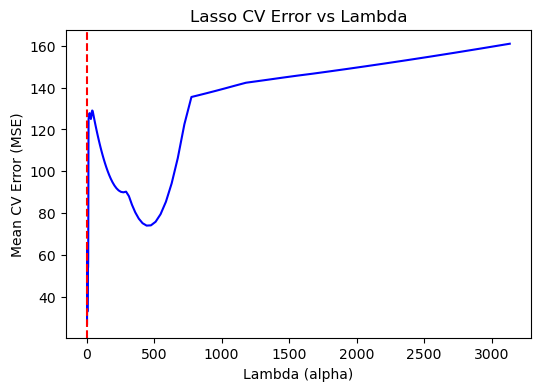

Optimal alpha: 3.134475200138519
Lasso coefficients:
X1     0.000000
X2     0.000000
X3     0.000000
X4     0.000000
X5     1.682323
X6     0.038189
X7     0.000000
X8     0.101443
X9    -0.031351
X10   -0.017806
dtype: float64


In [9]:
# e)
X_mat = data.drop(columns=['Y']).values
lasso = LassoCV(cv=10, random_state=42)
lasso.fit(X_mat, Y)

plt.figure(figsize=(6,4))
plt.plot(lasso.alphas_, np.mean(lasso.mse_path_, axis=1), 'b-')
plt.axvline(lasso.alpha_, color='r', linestyle='--')
plt.xlabel("Lambda (alpha)")
plt.ylabel("Mean CV Error (MSE)")
plt.title("Lasso CV Error vs Lambda")
plt.show()

print("Optimal alpha:", lasso.alpha_)
coeffs = pd.Series(lasso.coef_, index=data.columns[1:])
print("Lasso coefficients:")
print(coeffs)


In [10]:
# f) 
beta0, beta7 = 2, 10
Y2 = beta0 + beta7 * X**7 + epsilon

data2 = pd.DataFrame({"Y": Y2})
for i in range(1,11):
    data2[f"X{i}"] = X ** i

X2_mat = data2.drop(columns=['Y']).values
lasso2 = LassoCV(cv=10, random_state=42)
lasso2.fit(X2_mat, Y2)

coeffs2 = pd.Series(lasso2.coef_, index=data2.columns[1:])
print("Lasso coefficients for model with X^7:")
print(coeffs2)

# lasso nie potrafi odroznic ktora potega jest naprawde odpowiedzialna za Y, wiec wybiera X^9
# ktore jest blisko X^7

Lasso coefficients for model with X^7:
X1     0.000000
X2     0.000000
X3     0.000000
X4     0.000000
X5     0.000000
X6     0.000000
X7     0.000000
X8     0.000000
X9     1.818894
X10    0.034685
dtype: float64
